## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

In [2]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
remove_outliers = False

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
if remove_outliers:
    outliers = 'outliers_removed'
else:
    outliers = 'outliers_present'

In [3]:
outliers_indices = {
    'simulated': list(range(1035, 1050)) + list(range(1020, 1035)),
    'real': list(range(2370, 2385))
                    }

## Loading the data

In [4]:
data_path = '../data/DANE.xlsx'

In [5]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

## Preprocessing

### Some checks on the data

1. Let's check if column naming is consistent (inDs).

In [6]:
series_based_on_sample_name = pd.Series(inds_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [7]:
series_based_on_column = inds_df['seria'].reset_index(drop=True)

In [8]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything is fine. For inKs:

In [9]:
series_based_on_sample_name = pd.Series(inks_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [10]:
series_based_on_column = inks_df['seria'].reset_index(drop=True)

In [11]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything ok.

2. Let's check if naming is consistent across two sheets (i.e. for inDs and for inKs).

In [12]:
series_from_inds_sheet = inds_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [13]:
series_from_inks_sheet = inks_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [14]:
np.all(series_from_inds_sheet == series_from_inks_sheet)

False

It's not consistent, but it's not the problem, cause rows in both tables correspond to each other.

In [15]:
inks_df.shape == inds_df.shape

True

### Joining corresponding samples from inds and inks into one table

In [16]:
inks_df = inks_df.reset_index(drop=False)

In [17]:
inds_df = inds_df.reset_index(drop=False)

In [18]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [19]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Removing some data

1. Let's remove rows with missing values.

In [20]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [21]:
inDKs_df.dropna(inplace=True)

In [22]:
inDKs_df.shape

(2415, 64)

2. Let's keep only columns that we need.

In [23]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

If you want to keep use version with 29 numbers, just comment out the cell below.

In [24]:
inks_colnames = [
 'Al_inks',
 'S_inks',
 'Cr_inks',
 'Mn_inks',
 'Co_inks',
 'Cu_inks',
 'Zn_inks',
 'Pb_inks']

inds_colnames = [
 'Al_inds',
 'S_inds',
 'Cr_inds',
 'Mn_inds',
 'Co_inds',
 'Cu_inds',
 'Zn_inds',
 'Pb_inds']

### Creating features and labels matrices

In [25]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [26]:
X = np.array(inDKs_df[inds_colnames].values)
y = np.array(inDKs_df[inks_colnames].values)

if remove_outliers:
    if real_or_simulated == 'real':
        indices_to_remove = outliers_indices['real']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'simulated':
        indices_to_remove = outliers_indices['simulated']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'all':
        indices_to_remove = outliers_indices['simulated'] + \
                            [ind + 1425 for ind in outliers_indices['real']]
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

### Normalization

In [27]:
X = (X - np.mean(X, axis=0))/np.std(X, axis=0)
y = (y - np.mean(y, axis=0))/np.std(y, axis=0)

### Converting to tensors

In [28]:
X = torch.Tensor(X).to(device)
y = torch.Tensor(y).to(device)

### Train test split, datasets, dataloaders

15 slices from the same sample should either all go to train or all go to test.

In [29]:
if keep_sample_together:
    indices = list(range(int(X.shape[0]/15)))
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
    ind_train_all = [x for l in ind_train_all for x in l]
    ind_val_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_val]
    ind_val_all = [x for l in ind_val_all for x in l]
    ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
    ind_test_all = [x for l in ind_test_all for x in l]

else:
    indices = list(range(int(X.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

In [30]:
partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}

In [31]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_val = X[partition['val']]
y_val = y[partition['val']]

X_test = X[partition['test']]
y_test = y[partition['test']]

In [32]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [33]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [34]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=True)

## Building neural network

In [35]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [36]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [37]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
  )
)


In [39]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [40]:
EPOCHS = 5000
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 0.37382069826126096 test 0.39946604776147976
EPOCH 2:
LOSS train 0.3711430768171946 test 0.39753974218299426
EPOCH 3:
LOSS train 0.37210086584091184 test 0.39567123165288576
EPOCH 4:
LOSS train 0.36802106698354087 test 0.3938700270763836
EPOCH 5:
LOSS train 0.3713325579961141 test 0.392094239685106
EPOCH 6:
LOSS train 0.3735864500204722 test 0.39034124152198835
EPOCH 7:
LOSS train 0.3624326467514038 test 0.388593413136267
EPOCH 8:
LOSS train 0.3637471735477448 test 0.386901395800321
EPOCH 9:
LOSS train 0.35929739077885947 test 0.3853567778971625
EPOCH 10:
LOSS train 0.3586442450682322 test 0.38385059414566425
EPOCH 11:
LOSS train 0.36368379592895506 test 0.38232978860660616
EPOCH 12:
LOSS train 0.3560560623804728 test 0.3808010525646664
EPOCH 13:
LOSS train 0.353372178475062 test 0.3792609625320504
EPOCH 14:
LOSS train 0.35110204219818114 test 0.3776889241013221
EPOCH 15:
LOSS train 0.35176039934158326 test 0.37608211743597164
EPOCH 16:
LOSS train 0.3489371955394745

LOSS train 0.1930963784456253 test 0.2149333949615373
EPOCH 129:
LOSS train 0.18643990208705266 test 0.21464619548763794
EPOCH 130:
LOSS train 0.19092585543791454 test 0.2143809857814887
EPOCH 131:
LOSS train 0.18847343822320303 test 0.21410098585143963
EPOCH 132:
LOSS train 0.18829914132754008 test 0.21382047352814895
EPOCH 133:
LOSS train 0.18954906314611436 test 0.21355665610490007
EPOCH 134:
LOSS train 0.18976715703805289 test 0.21328292061491844
EPOCH 135:
LOSS train 0.18758632093667985 test 0.21301997044195053
EPOCH 136:
LOSS train 0.1879403273264567 test 0.21276083586671954
EPOCH 137:
LOSS train 0.1874048764506976 test 0.21250875963295346
EPOCH 138:
LOSS train 0.18722073982159296 test 0.212263264884212
EPOCH 139:
LOSS train 0.18881267309188843 test 0.21202518148868352
EPOCH 140:
LOSS train 0.18553946961959203 test 0.21176130281603175
EPOCH 141:
LOSS train 0.18614125152428945 test 0.21153910264881873
EPOCH 142:
LOSS train 0.18631482422351836 test 0.2112923169674402
EPOCH 143:
LOS

LOSS train 0.17339661767085393 test 0.1979145860149068
EPOCH 253:
LOSS train 0.17402562648057937 test 0.19786981346305482
EPOCH 254:
LOSS train 0.17197488397359847 test 0.1977733367625971
EPOCH 255:
LOSS train 0.1733062987526258 test 0.19772850214185553
EPOCH 256:
LOSS train 0.17340545852979025 test 0.19767133122229058
EPOCH 257:
LOSS train 0.17295398612817128 test 0.1976017775958863
EPOCH 258:
LOSS train 0.17818202873071035 test 0.19756182456701438
EPOCH 259:
LOSS train 0.1728054702281952 test 0.1975255793087786
EPOCH 260:
LOSS train 0.1758615622917811 test 0.1974632307061806
EPOCH 261:
LOSS train 0.17379849006732304 test 0.19738392343293437
EPOCH 262:
LOSS train 0.17069630175828934 test 0.19733531759785755
EPOCH 263:
LOSS train 0.17468013862768808 test 0.19728966705948422
EPOCH 264:
LOSS train 0.17699457556009293 test 0.1972289501108985
EPOCH 265:
LOSS train 0.1759845828016599 test 0.197156250021781
EPOCH 266:
LOSS train 0.17321903308232625 test 0.19710230747503893
EPOCH 267:
LOSS tr

LOSS train 0.1694510782758395 test 0.18994560924129208
EPOCH 378:
LOSS train 0.1649704948067665 test 0.1898859209201721
EPOCH 379:
LOSS train 0.1645874430735906 test 0.1898117632630202
EPOCH 380:
LOSS train 0.1678335815668106 test 0.18975769383273633
EPOCH 381:
LOSS train 0.1670314426223437 test 0.18969939173224304
EPOCH 382:
LOSS train 0.1687412977218628 test 0.18962674137536537
EPOCH 383:
LOSS train 0.16411779423554737 test 0.1895717664835801
EPOCH 384:
LOSS train 0.16461960971355438 test 0.18948387325303648
EPOCH 385:
LOSS train 0.1654479886094729 test 0.1894379587917286
EPOCH 386:
LOSS train 0.16906170199314755 test 0.1893630082994761
EPOCH 387:
LOSS train 0.16600627650817235 test 0.18928534401036937
EPOCH 388:
LOSS train 0.16728907575209936 test 0.18920691794567351
EPOCH 389:
LOSS train 0.16971578349669775 test 0.18915589174205596
EPOCH 390:
LOSS train 0.16389446357885998 test 0.18908287556437048
EPOCH 391:
LOSS train 0.16634970208009084 test 0.18899007235879298
EPOCH 392:
LOSS tr

LOSS train 0.159894959628582 test 0.18209540208041916
EPOCH 502:
LOSS train 0.1600419193506241 test 0.18203023471339272
EPOCH 503:
LOSS train 0.1593149036169052 test 0.18196236152649234
EPOCH 504:
LOSS train 0.15955406576395034 test 0.18189617887131607
EPOCH 505:
LOSS train 0.15893737822771073 test 0.18182873789329027
EPOCH 506:
LOSS train 0.16204522997140886 test 0.18178699130489342
EPOCH 507:
LOSS train 0.15847796152035395 test 0.18170408129800056
EPOCH 508:
LOSS train 0.1582783485452334 test 0.18163743094342527
EPOCH 509:
LOSS train 0.16192780683437982 test 0.18159339328028462
EPOCH 510:
LOSS train 0.1600371077656746 test 0.18149443032262427
EPOCH 511:
LOSS train 0.15795773714780809 test 0.18143918679730184
EPOCH 512:
LOSS train 0.16191434959570566 test 0.1813886011227595
EPOCH 513:
LOSS train 0.1598348468542099 test 0.18132900273693459
EPOCH 514:
LOSS train 0.1630474905172984 test 0.18126305954542404
EPOCH 515:
LOSS train 0.15940503577391307 test 0.18118613685903526
EPOCH 516:
LOSS

...

LOSS train 0.13533948808908464 test 0.1457822474238403
EPOCH 4424:
LOSS train 0.13154001235961915 test 0.14578128414321112
EPOCH 4425:
LOSS train 0.13137964010238648 test 0.14586390153163617
EPOCH 4426:
LOSS train 0.13005590190490088 test 0.14575338652203204
EPOCH 4427:
LOSS train 0.1345737834771474 test 0.14577223101869904
EPOCH 4428:
LOSS train 0.13157164057095846 test 0.1457764038972279
EPOCH 4429:
LOSS train 0.13149926215410232 test 0.1457190497751361
EPOCH 4430:
LOSS train 0.13046805163224537 test 0.1457569772622492
EPOCH 4431:
LOSS train 0.13035172124703726 test 0.14573585995478752
EPOCH 4432:
LOSS train 0.13309290359417597 test 0.14575609081476834
EPOCH 4433:
LOSS train 0.13076373934745789 test 0.14573852809755358
EPOCH 4434:
LOSS train 0.1333430752158165 test 0.1457346107851228
EPOCH 4435:
LOSS train 0.13171889533599218 test 0.14574658861345233
EPOCH 4436:
LOSS train 0.1331550285220146 test 0.1457191582963904
EPOCH 4437:
LOSS train 0.13181621134281157 test 0.14575825350389934
E

LOSS train 0.13013137578964235 test 0.14532919263941532
EPOCH 4547:
LOSS train 0.1321932370464007 test 0.145320051685207
EPOCH 4548:
LOSS train 0.13240741342306137 test 0.1453088861706958
EPOCH 4549:
LOSS train 0.1298717831571897 test 0.14529241029149997
EPOCH 4550:
LOSS train 0.1319672793149948 test 0.14532856276262682
EPOCH 4551:
LOSS train 0.13051349992553393 test 0.14526090769802932
EPOCH 4552:
LOSS train 0.13092722843090693 test 0.14534799757897546
EPOCH 4553:
LOSS train 0.13056109448273975 test 0.14526841673020496
EPOCH 4554:
LOSS train 0.13377259994546573 test 0.14534195520438825
EPOCH 4555:
LOSS train 0.130000601708889 test 0.14526879847412216
EPOCH 4556:
LOSS train 0.13326273063818614 test 0.14528803982025718
EPOCH 4557:
LOSS train 0.130717471241951 test 0.14528219166595496
EPOCH 4558:
LOSS train 0.13145924607912698 test 0.14532475379019913
EPOCH 4559:
LOSS train 0.1311845769484838 test 0.14529625461369322
EPOCH 4560:
LOSS train 0.13178485582272212 test 0.14528297555226038
EPO

LOSS train 0.13072888205448788 test 0.1449030729754988
EPOCH 4670:
LOSS train 0.1297209456562996 test 0.1448424961167247
EPOCH 4671:
LOSS train 0.13206372459729512 test 0.1448921471656788
EPOCH 4672:
LOSS train 0.13463865915934245 test 0.14487732849498405
EPOCH 4673:
LOSS train 0.13149570027987162 test 0.1449035684930982
EPOCH 4674:
LOSS train 0.131780306994915 test 0.14485645201250016
EPOCH 4675:
LOSS train 0.12876190145810446 test 0.1448534027293448
EPOCH 4676:
LOSS train 0.1316146453221639 test 0.1448959608544937
EPOCH 4677:
LOSS train 0.13161128610372544 test 0.14485129307932365
EPOCH 4678:
LOSS train 0.12902973343928656 test 0.14486046403060296
EPOCH 4679:
LOSS train 0.13578550964593888 test 0.14486889131984232
EPOCH 4680:
LOSS train 0.13003216485182445 test 0.14484625010062818
EPOCH 4681:
LOSS train 0.13209726239244143 test 0.144813539277122
EPOCH 4682:
LOSS train 0.1291597088177999 test 0.14487477470243323
EPOCH 4683:
LOSS train 0.13225741783777872 test 0.14482754378677895
EPOCH

LOSS train 0.12929156372944514 test 0.14449064212216847
EPOCH 4793:
LOSS train 0.13088015814622242 test 0.14452621933288765
EPOCH 4794:
LOSS train 0.1301155428091685 test 0.1445298889135136
EPOCH 4795:
LOSS train 0.1302182783683141 test 0.1445353504493987
EPOCH 4796:
LOSS train 0.13091723670562108 test 0.14455179955740893
EPOCH 4797:
LOSS train 0.13171102205912272 test 0.1445470760397104
EPOCH 4798:
LOSS train 0.12969902058442434 test 0.144529570466752
EPOCH 4799:
LOSS train 0.13185191998879114 test 0.14452947001310362
EPOCH 4800:
LOSS train 0.1308552180727323 test 0.14446062111251412
EPOCH 4801:
LOSS train 0.12971568952004114 test 0.1445097859763766
EPOCH 4802:
LOSS train 0.1301840951045354 test 0.14446728089419397
EPOCH 4803:
LOSS train 0.12929262419541676 test 0.1444822068212411
EPOCH 4804:
LOSS train 0.13046566098928453 test 0.14446167295941345
EPOCH 4805:
LOSS train 0.13167714476585388 test 0.1445116459278247
EPOCH 4806:
LOSS train 0.13228416194518408 test 0.14445957600275983
EPOC

LOSS train 0.1307457720239957 test 0.14409091899954324
EPOCH 4915:
LOSS train 0.13004130025704702 test 0.14412767332294035
EPOCH 4916:
LOSS train 0.12995702226956685 test 0.14416670748543603
EPOCH 4917:
LOSS train 0.13388687372207642 test 0.14408991609817645
EPOCH 4918:
LOSS train 0.12958450814088185 test 0.14415420716200372
EPOCH 4919:
LOSS train 0.12940893123547237 test 0.14410422642293
EPOCH 4920:
LOSS train 0.13088240325450898 test 0.14412494365503822
EPOCH 4921:
LOSS train 0.13038592015703518 test 0.14410233237504896
EPOCH 4922:
LOSS train 0.12947279115517935 test 0.14411195311078312
EPOCH 4923:
LOSS train 0.12866181979576746 test 0.14406804443871135
EPOCH 4924:
LOSS train 0.12916606813669204 test 0.14411224173015566
EPOCH 4925:
LOSS train 0.13169509172439575 test 0.14411895294282315
EPOCH 4926:
LOSS train 0.1302059402068456 test 0.14410300263807208
EPOCH 4927:
LOSS train 0.13149836013714472 test 0.14408812355674325
EPOCH 4928:
LOSS train 0.13059662729501725 test 0.144094623041032

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

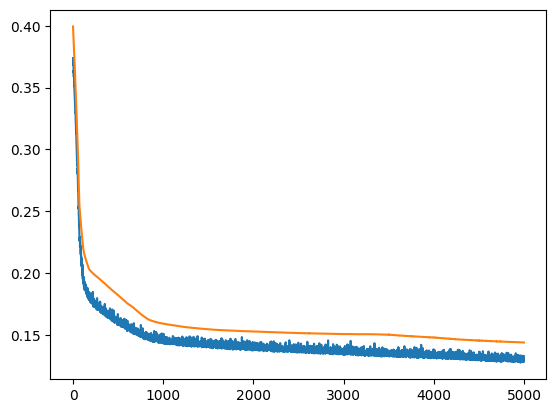

In [41]:
#no keeping one sample together
#4 layers each 8 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

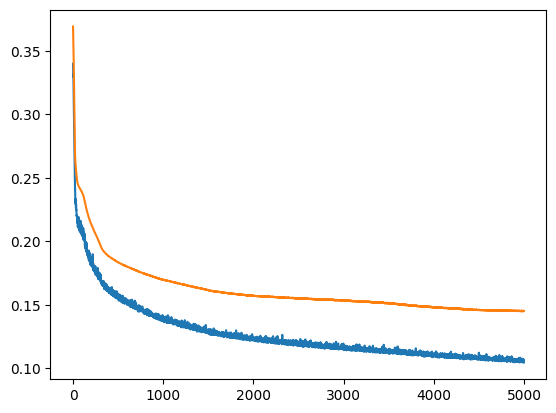

In [41]:
#no keeping one sample together
#4 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

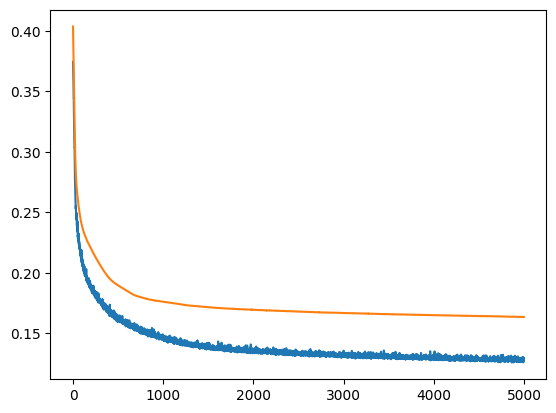

In [38]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

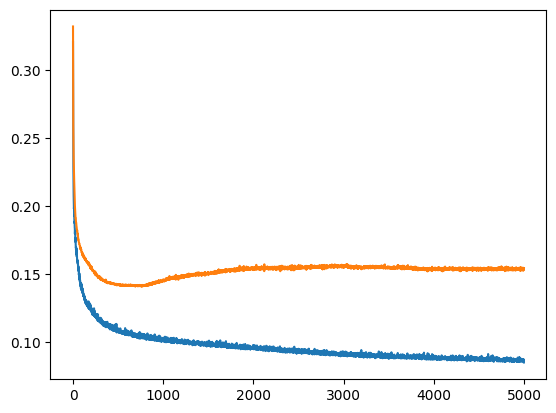

In [38]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

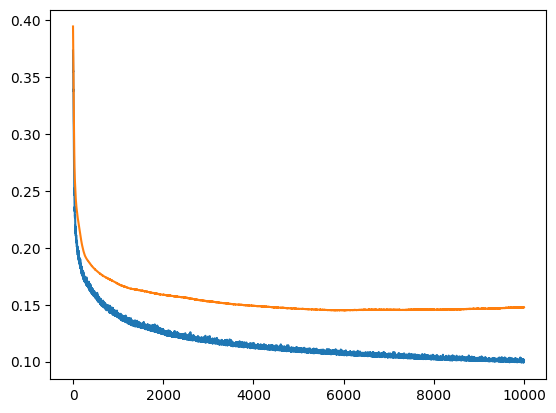

In [38]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

## Test set

In [42]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    res = torch.concat((res, abs(outputs-labels)), axis=0)
    lab = torch.concat((lab, labels), axis=0)
    out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [47]:
lab

tensor([[-0.2766,  2.2387,  0.6446,  ..., -0.0732, -0.1286, -0.0917],
        [-0.2766,  2.2387,  0.6446,  ..., -0.0732, -0.1286, -0.0917],
        [-0.1264,  0.0796, -0.1687,  ..., -0.0725, -0.0783, -0.0770],
        ...,
        [-0.1534, -0.1260, -0.1700,  ..., -0.0736, -0.1950, -0.0927],
        [-0.2794, -0.1251, -0.1701,  ..., -0.0647,  1.2644,  0.1843],
        [-0.2665, -0.1575, -0.1701,  ..., -0.0738, -0.2081, -0.0966]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [49]:
out

tensor([[-0.2012,  1.0621, -0.0849,  ...,  0.0287,  1.6572, -0.0805],
        [-0.2012,  1.0621, -0.0849,  ...,  0.0287,  1.6572, -0.0805],
        [-0.1925, -0.1284, -0.1667,  ..., -0.0753, -0.1848, -0.0796],
        ...,
        [-0.1219, -0.1151, -0.1577,  ..., -0.0803, -0.0916, -0.0728],
        [-0.2568, -0.1474, -0.1687,  ..., -0.0743, -0.1724, -0.0922],
        [-0.2488, -0.1438, -0.1692,  ..., -0.0736, -0.1720, -0.0923]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [53]:
res

tensor([[7.5492e-02, 1.1766e+00, 7.2943e-01,  ..., 1.0198e-01, 1.7858e+00,
         1.1211e-02],
        [7.5492e-02, 1.1766e+00, 7.2943e-01,  ..., 1.0198e-01, 1.7858e+00,
         1.1211e-02],
        [6.6105e-02, 2.0794e-01, 2.0811e-03,  ..., 2.8437e-03, 1.0652e-01,
         2.6176e-03],
        ...,
        [3.1484e-02, 1.0902e-02, 1.2325e-02,  ..., 6.6911e-03, 1.0341e-01,
         1.9886e-02],
        [2.2569e-02, 2.2297e-02, 1.3337e-03,  ..., 9.6019e-03, 1.4368e+00,
         2.7656e-01],
        [1.7671e-02, 1.3685e-02, 8.6679e-04,  ..., 2.2545e-04, 3.6056e-02,
         4.3181e-03]], device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [54]:
torch.mean(res, axis=0)

tensor([0.1740, 0.1019, 0.1329, 0.3091, 0.1423, 0.0467, 0.1324, 0.0432],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [ ]:
Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [56]:
torch.mean(res)

tensor(0.1353, device='cuda:0', grad_fn=<MeanBackward0>)

Below: some experiments, visualisations...

In [60]:
dim_nr = 0
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

In [61]:
#torch.max(out, axis=0)

(0.0, 4.0)

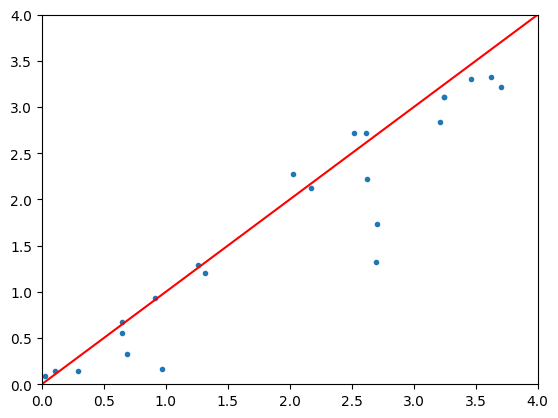

In [62]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [0,20],[0,20], 'red' )
plt.xlim(0, 4)
plt.ylim(0, 4)

In [63]:
torch.mean(res, 0)

tensor([0.1740, 0.1019, 0.1329, 0.3091, 0.1423, 0.0467, 0.1324, 0.0432],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [64]:
mean_loss

0.13389697226871183

## Interpretability

...